# Análise do motivo "OUTROS"

## Comparativo entre os modelos **MiniLM** e **BERT** 

* **Objetivo**: Criação de uma matriz de semelhança entre os motivos existentes com as justificativas do motivo "OUTROS".
    * Avaliar o pareamento sujestivo dos **motivos existentes** com as **justificativas preenchidas pelo contribuinte** entre os modelos.
 
### MiniLM : 384 dimensões Euclidianas

### BERT: 768 dimensões Euclidianas

## Moitvo "OUTROS"

* O motivo "OUTROS" atua como uma categoria "vazia" na contestação de Extrato Fronteiras, mascarando problemas taxonômicos, nomenclaturas ou ambos.

## Imports

In [ ]:
#Bilbiotecas utilizadas (Parte 1)
!pip install pandas numpy sentence-transformers scikit-learn tqdm umap-learn hdbscan --trusted-host pypi.org --trusted-host files.pythonhosted.org --trusted-host pypi.python.org

In [ ]:
#Bilbiotecas utilizadas (Parte 2)
!pip install hdbscan --user

In [1]:
# --- BIBLIOTECAS DE SUPORTE E MANIPULAÇÃO ---
from sentence_transformers import SentenceTransformer      # Carrega a rede neural localmente
from sklearn.metrics.pairwise import cosine_similarity     # Calcula o ângulo vetorial
import numpy as np                                         # Operações matemáticas e manipulação de arrays/matrizes
import pandas as pd                                        # Manipulação, limpeza e análise de dados tabulares
import re                                                  # Expressões regulares para limpeza e padronização
import unicodedata                                         # Normalização de caracteres e remoção de acentuação
import matplotlib.pyplot as plt                            # Para visualizarmos o gráfico de Pareto e Histogramas
import seaborn as sns                                      # Para descritiva visual elegante

# --- CONFIGURAÇÕES DO AMBIENTE ---
import warnings
warnings.filterwarnings("ignore")  # Suprime alertas de sistema para manter o output limpo
pd.set_option('display.max_columns', None)
# Define a largura máxima da coluna como ilimitada (None) ou um valor alto (ex: 500)
pd.set_option('display.max_colwidth', None)
# Opcional: Se quiser ver mais linhas de uma vez para validar a limpeza
pd.set_option('display.max_rows', 20)

## Carregamento do modelo

### OBS

Necessidade de rodar os modelos de embedding localmente. Fazer o download dos modelos:

* **Bert** - https://huggingface.co/intfloat/multilingual-e5-base/tree/main
* **MiniLM** - https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/tree/main

In [2]:
# --- FASE 1: INICIALIZAÇÃO OFF-LINE DAS REDES NEURAIS ---

# Carregamento do BERT E5 (768D) baixado manualmente
modelo_bert = SentenceTransformer('./modelo_bert_e5/')
print(f"✅ BERT E5 carregado com sucesso! Limite: {modelo_bert.max_seq_length} tokens.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ BERT E5 carregado com sucesso! Limite: 512 tokens.


## Saneamento do texto

In [3]:
def preprocessar_texto_completo(texto):
    """
    Função completa de limpeza e padronização de textos.
    Aplica:
      - Minúsculas
      - Remoção de acentos
      - Remoção de URLs
      - Remoção de números longos (≥7 dígitos)
      - Manutenção apenas de letras, números e espaços
      - Remoção de espaços extras

    Parâmetros:
    - texto: string a ser processada

    Retorna:
    - string limpa ou string vazia se entrada inválida
    """
    if not isinstance(texto, str):
        return ""

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Remoção de acentos (normalização Unicode)
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')

    # 3. Remoção de URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)

    # 4. Remoção de números longos (7 ou mais dígitos consecutivos)
    texto = re.sub(r'\b\d{7,}\b', '', texto)

    # 5. Manutenção apenas de letras, números e espaços
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)

    # 6. Remoção de espaços extras (incluindo duplicados e bordas)
    texto = " ".join(texto.split())

    return texto

# 1 - Importação e tratamento das justificaitivas

In [4]:
#Tabela das justificativas dos OUTROS
df = pd.read_csv('justificativa_outros.csv', engine='python', encoding='utf-16', sep=',', on_bad_lines='skip')
#Visualização
df.head(3)

,procontenf_tx_justificativa
0,ICMS CALCULADO INCORRETAMENTE
1,"PAGO NO DAE 85880000975-7 59660192010-0 58040000010-5 08175050000-6 R$ 1.054,50"
2,CONTRIBUINTE ENQUADRADO NO INCISO II DO ART. 363-A DO DECRETO Nº 44.650/2017


In [5]:
#Volumetria
volumetria = df.shape[0] 
print(f"Volumetria: {volumetria}") #32.437

Volumetria: 32437


## Lapidação textual

In [7]:
##Saneamento do texto
df['justificativa_limpa'] = df['procontenf_tx_justificativa'].fillna('sem_justificativa_informada').apply(preprocessar_texto_completo) #Feature Textual Principal
##Variável total de palavras da justificativa - aplicada na justificativa limpa
df['total_palavras'] = df['justificativa_limpa'].fillna("").apply(lambda x: len(str(x).split()))
#Distribuição de palavras por justificativa
####Descritiva do total de palavras####
df['total_palavras'].describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99])

count    32437.000000
mean        39.288960
std         45.993426
min          0.000000
10%          7.000000
20%         10.000000
30%         14.000000
40%         20.000000
50%         26.000000
60%         33.000000
70%         42.000000
80%         55.000000
90%         82.000000
95%        119.000000
96%        136.000000
97%        156.000000
98%        174.000000
99%        249.000000
max        636.000000
Name: total_palavras, dtype: float64

In [8]:
#Visualização
df.head(6)

,procontenf_tx_justificativa,justificativa_limpa,total_palavras
0,ICMS CALCULADO INCORRETAMENTE,icms calculado incorretamente,3
1,"PAGO NO DAE 85880000975-7 59660192010-0 58040000010-5 08175050000-6 R$ 1.054,50",pago no dae 7 0 5 6 r 1 054 50,11
2,CONTRIBUINTE ENQUADRADO NO INCISO II DO ART. 363-A DO DECRETO Nº 44.650/2017,contribuinte enquadrado no inciso ii do art 363 a do decreto no 44 650 2017,15
3,"APROPRIAR PAGAMENTO ST, POR GNRE , EM 31.03.2026 NO VALOR DE R$ 91,15, REALIZADO PELO FORNECEDOR(CÓDIGO 042-6).",apropriar pagamento st por gnre em 31 03 2026 no valor de r 91 15 realizado pelo fornecedor codigo 042 6,21
4,"ITEM DA NOTA FISCAL SE REFERE A EXTRATOR SMART, POSSUI ISENÇÃO NO ART. 51 ANEXO 07 DO RICMS-PE",item da nota fiscal se refere a extrator smart possui isencao no art 51 anexo 07 do ricms pe,19
5,"CONTRIBUINTE REGULAR QUANTO AO CUMPRIMENTO DAS OBRIGAÇÕES TRIBUTÁRIAS NOS TERMOS DO ARTIGO 393-A DO DECRETO Nº 44.650/2017 E CÁLCULO DO ICMS ANTECIPADO NOS TERMOS DO DECRETO Nº 44.650/2017, ART. 340, PARÁGRAFO ÚNICO, E ART. 363-A, III ONDE DEVERIA SER COBRADO R$ 24.728,23.",contribuinte regular quanto ao cumprimento das obrigacoes tributarias nos termos do artigo 393 a do decreto no 44 650 2017 e calculo do icms antecipado nos termos do decreto no 44 650 2017 art 340 paragrafo unico e art 363 a iii onde deveria ser cobrado r 24 728 23,50


In [9]:
#Visualizando as justificativas sem texto
df.loc[df.total_palavras ==0].head()

,procontenf_tx_justificativa,justificativa_limpa,total_palavras
3215,..,,0
7532,007513240,,0
9707,086658263,,0
9800,...........................................................................,,0
31468,.,,0


In [10]:
df.loc[df.total_palavras ==0].shape[0]#5 justificativas sem palavras

5

In [14]:
#Textos com até 5 palavras
##Vale a pena pegar os texto com três ou mais palavras
df.loc[df.total_palavras <5].head(20)

,procontenf_tx_justificativa,justificativa_limpa,total_palavras
0,ICMS CALCULADO INCORRETAMENTE,icms calculado incorretamente,3
26,O CONTRIBUINTE É ISENTO,o contribuinte e isento,4
28,PRODUTO TRIBUTADO/ SUBSTITUÍDO,produto tributado substituido,3
88,FAVOR REVER ESSE VALOR,favor rever esse valor,4
94,NOTAS NÃO RECEBIDAS,notas nao recebidas,3
105,DIFAL - VALOR SUGERIDO,difal valor sugerido,3
157,PRODUTOS ISENTOS.,produtos isentos,2
204,EMPRESA OPTANTE PELO MEI,empresa optante pelo mei,4
215,"NF DEV, 14163",nf dev 14163,3
242,NF DEV 14113,nf dev 14113,3


## Distribuição dos tokens

In [15]:
# --- CORREÇÃO DA CONTAGEM DE TOKENS (SISTEMATIZADA) ---

print("Recalculando tokens reais...")

# Usamos o tokenizer diretamente para acessar a lista de IDs
# O método 'encode' do tokenizer (não do modelo) nos dá a lista real
df['qtd_tokens_bert'] = df['justificativa_limpa'].apply(lambda x: len(modelo_bert.tokenizer.encode(str(x), add_special_tokens=False)))

print("✅ Nova Descritiva de Tokens:")
print(df['qtd_tokens_bert'].describe(percentiles=[0.1, 0.5, 0.9, 0.95, 0.99])) #Percentil 95: 164 tokens

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (667 > 512). Running this sequence through the model will result in indexing errors


Recalculando tokens reais...
✅ Nova Descritiva de Tokens:
count    32437.000000
mean        55.069396
std         63.597565
min          0.000000
10%         10.000000
50%         37.000000
90%        116.000000
95%        164.000000
99%        337.000000
max       1060.000000
Name: qtd_tokens_bert, dtype: float64


# 2 - Data frame final das justificativas a serem vetorizadas

## Critérios:

* Mais que 3 palavras;
* Menos que 165 tokens.

In [18]:
# --- FASE DE HIGIENIZAÇÃO ESTRUTURAL ---

# 1. Aplicando a dupla trava (Negócio + Técnica)
df_final = df[
    (df['total_palavras'] > 3) &            # Perspectiva 1: Mínimo de conteúdo
    (df['qtd_tokens_bert'] <= 164)          # Perspectiva 2: Limite de leitura da IA
].copy()

# 2. Configurando o modelo para ler exatamente o que definimos

percentual = (len(df_final) / len(df)) * 100
print(f"📊 Base Limpa: {len(df_final):,} registros ({percentual:.2f}% da base original)") #Trabalhar com 30.090 justificativas

📊 Base Limpa: 30,090 registros (92.76% da base original)


# 3 - Vetorização

In [19]:
# --- FASE 1: GERAÇÃO DA MATRIZ SEMÂNTICA (EMBEDDINGS) ---

print(f"🚀 Iniciando vetorização de {len(df_final):,} justificativas...")
print(f"📏 Dimensão final esperada: ({len(df_final):,}, 768)")

# O modelo processará em blocos de 64 frases para otimizar a memória
# convert_to_numpy=True garante que teremos uma matriz pronta para cálculos estatísticos
embeddings = modelo_bert.encode(
    df_final['justificativa_limpa'].astype(str).tolist(), 
    batch_size=64, 
    show_progress_bar=True, 
    convert_to_numpy=True
)

print("\n✅ Vetorização concluída com sucesso!")
print(f"💎 Matriz 'embeddings' criada: {embeddings.shape}")

# Uma pequena amostra do primeiro vetor (os primeiros 5 números das 384 dimensões)
print(f"Amostra do primeiro vetor: {embeddings[0][:5]}")

🚀 Iniciando vetorização de 30,090 justificativas...
📏 Dimensão final esperada: (30,090, 768)


Batches:   0%|          | 0/471 [00:00<?, ?it/s]


✅ Vetorização concluída com sucesso!
💎 Matriz 'embeddings' criada: (30090, 768)
Amostra do primeiro vetor: [-0.01210881  0.05203638 -0.01926445  0.01229255  0.03546907]


In [20]:
# --- SALVAMENTO AUTOMÁTICO PÓS-VETORIZAÇÃO ---

try:
    # 1. Salva a matriz de Embeddings (768D) em formato binário otimizado
    np.save('embeddings_sefaz_full.npy', embeddings)
    
    # 2. Salva o DataFrame higienizado para manter a paridade com os vetores
    df_final.to_csv('df_final_processado.csv', index=False)
    
    print("\n" + "="*40)
    print("💾 BACKUP AUTOMÁTICO CONCLUÍDO!")
    print(f"📂 Arquivo de vetores: embeddings_sefaz_full.npy")
    print(f"📂 Arquivo de dados: df_final_processado.csv")
    print("="*40)

except NameError:
    print("⚠️ Erro: A variável 'embeddings' ainda não foi gerada.")
except Exception as e:
    print(f"❌ Ocorreu um erro no salvamento: {e}")


💾 BACKUP AUTOMÁTICO CONCLUÍDO!
📂 Arquivo de vetores: embeddings_sefaz_full.npy
📂 Arquivo de dados: df_final_processado.csv


# 4 - Tabela referente aos motivos de contestação e vetorização

In [21]:
#Tabela das justificativas dos OUTROS
df_motivos = pd.read_csv('motivos_contestacao.csv', engine='python', encoding='utf-16', sep=',', on_bad_lines='skip')
#Visualização
df_motivos.head(3)

,cmtmotivo_ds
0,CONVÊNIO 01/99
1,CARGA RECUPERADA
2,PRODUTO GOZA DE IMUNIDADE/NAO-INCIDENCIA


In [22]:
#Volumetria
df_motivos.shape[0] #322

322

In [24]:
# 1. Aplicar a sua função universal na lista de motivos
df_motivos['motivo_limpo'] = df_motivos['cmtmotivo_ds'].apply(preprocessar_texto_completo)

# 2. Remover o 'outros' e duplicatas
df_motivos_vivos = df_motivos[df_motivos['motivo_limpo'] != 'outros'].copy()
lista_motivos_unicos = df_motivos_vivos['motivo_limpo'].unique().tolist()

In [25]:
#Visualização
df_motivos.head(30)

,cmtmotivo_ds,motivo_limpo
0,CONVÊNIO 01/99,convenio 01 99
1,CARGA RECUPERADA,carga recuperada
2,PRODUTO GOZA DE IMUNIDADE/NAO-INCIDENCIA,produto goza de imunidade nao incidencia
3,REMESSA/RETORNO DE INDUSTRIALIZAÇÃO,remessa retorno de industrializacao
4,INSUMO PARA INDÚSTRIA,insumo para industria
...,...,...
25,"VEÍCULOS NOVOS, ALÍQUOTA REDUZIDA DE 12% - ART. 18, I, 'A', LEI 15.730/2016",veiculos novos aliquota reduzida de 12 art 18 i a lei 15 730 2016
26,"RAÇÃO PARA ANIMAIS DOMÉSTICOS, ARTS 55 E 56, ANEXO 37, DECRETO 44.650/2017.",racao para animais domesticos arts 55 e 56 anexo 37 decreto 44 650 2017
27,CRENDENCIAMENTO MASSAS E BISCOITOS PORT. 072/2007 E PORT. 192/2011,crendenciamento massas e biscoitos port 072 2007 e port 192 2011
28,DANFE CANCELADO PELO EMITENTE,danfe cancelado pelo emitente


## Vetorização

In [26]:
#Vetorizar os alvos (os motivos oficiais limpos)
embeddings_motivos = modelo_bert.encode(lista_motivos_unicos)

# 5 - Distância Cosseno

**Matemática de comparação**

In [27]:
# --- FASE DE PAREAMENTO SEMÂNTICO ---
print(f"🎯 Calculando proximidade para {len(df_final):,} justificativas contra {len(lista_motivos_unicos)} motivos...")

# 1. Cálculo da Similaridade de Cosseno (Matriz de 214k x 317)
matriz_sim = cosine_similarity(embeddings, embeddings_motivos)

# 2. Identificação do Melhor Match
# np.argmax pega o índice do motivo com maior score
indices_vencedores = np.argmax(matriz_sim, axis=1)
scores_confianca = np.max(matriz_sim, axis=1)

# 3. Registro dos Resultados no DataFrame
df_final['motivo_ia_sugerido'] = [lista_motivos_unicos[i] for i in indices_vencedores]
df_final['confianca_ia'] = scores_confianca

print("✅ Mapeamento concluído!")

🎯 Calculando proximidade para 30,090 justificativas contra 313 motivos...
✅ Mapeamento concluído!


In [28]:
# --- TABELA DE FREQUÊNCIA: O DIAGNÓSTICO DO 'OUTROS' ---

print("📊 DISTRIBUIÇÃO SEMÂNTICA (O QUE O USUÁRIO REALMENTE QUERIA DIZER):")
print("-" * 60)

# Calculando Frequência Absoluta e Percentual
contagem = df_final['motivo_ia_sugerido'].value_counts()
percentual = df_final['motivo_ia_sugerido'].value_counts(normalize=True) * 100

# Criando o DataFrame de Diagnóstico para exibição
df_diagnostico = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual.round(2)
}).head(20) # Mostra os 20 principais motivos que estavam "escondidos"

display(df_diagnostico)

# Insight Automático
top_motivo = df_diagnostico.index[0]
top_perc = df_diagnostico.iloc[0, 1]
print(f"\n💡 CONCLUSÃO: O motivo '{top_motivo}' representa {top_perc}% do volume que hoje cai em 'Outros'.")

📊 DISTRIBUIÇÃO SEMÂNTICA (O QUE O USUÁRIO REALMENTE QUERIA DIZER):
------------------------------------------------------------


,Quantidade,Percentual (%)
motivo_ia_sugerido,,
icms recolhido na nf emitida pelo armazem geral logistica a partir de 10 17 art 486 dec 44650 17,3423,11.38
mercadoria sujeita a nao incidencia do icms,1305,4.34
nota fiscal com icms antecipado pago,1276,4.24
icms recolhido na nf emitida pelo armazem geral logistica,862,2.86
nota fiscal indevido o icms antecipado,828,2.75
mercadoria com icms recolhido por subst tributaria,827,2.75
produto de substituicao pago por gnre art 12 inc ii b anexo 37 decreto 44 650 2017,688,2.29
produtos com aliquota diferente de 20 5,656,2.18
erro de digitacao nos dados da nota fiscal,645,2.14



💡 CONCLUSÃO: O motivo 'icms recolhido na nf emitida pelo armazem geral logistica a partir de 10 17 art 486 dec 44650 17' representa 11.38% do volume que hoje cai em 'Outros'.


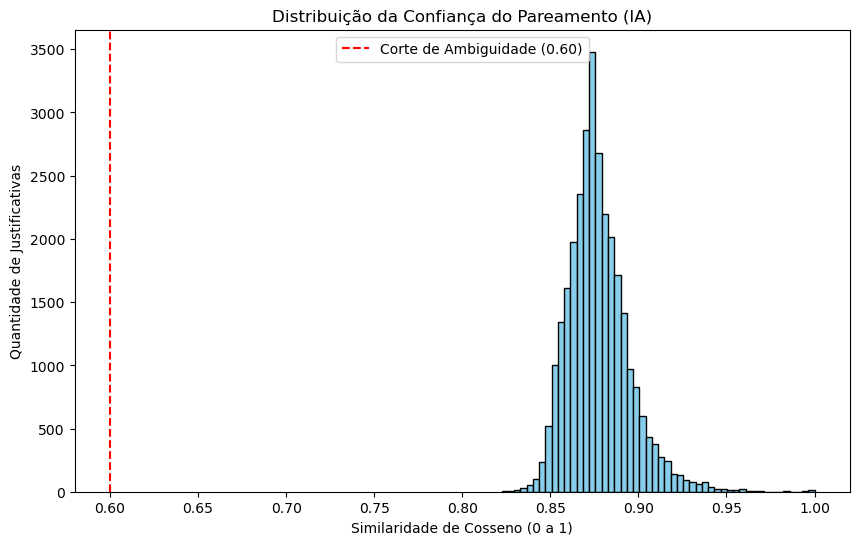

In [29]:
# --- HISTOGRAMA DE CONFIANÇA SEMÂNTICA ---
plt.figure(figsize=(10, 6))
plt.hist(df_final['confianca_ia'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0.6, color='red', linestyle='--', label='Corte de Ambiguidade (0.60)')
plt.title('Distribuição da Confiança do Pareamento (IA)')
plt.xlabel('Similaridade de Cosseno (0 a 1)')
plt.ylabel('Quantidade de Justificativas')
plt.legend()
plt.show()

# Estatística de Ambiguidade
#orfaos = df_final[df_final['confianca_ia'] < 0.60].shape[0]
#print(f"⚠️ Alerta: {orfaos} justificativas ({orfaos/len(df_final)*100:.2f}%) não possuem um motivo correspondente claro no sistema.")

In [30]:
df_final.head(3)

,procontenf_tx_justificativa,justificativa_limpa,total_palavras,qtd_tokens_bert,motivo_ia_sugerido,confianca_ia
1,"PAGO NO DAE 85880000975-7 59660192010-0 58040000010-5 08175050000-6 R$ 1.054,50",pago no dae 7 0 5 6 r 1 054 50,11,13,pagamento de dae,0.881211
2,CONTRIBUINTE ENQUADRADO NO INCISO II DO ART. 363-A DO DECRETO Nº 44.650/2017,contribuinte enquadrado no inciso ii do art 363 a do decreto no 44 650 2017,15,21,isencao anexo 7 do decreto 44 650 2017,0.911468
3,"APROPRIAR PAGAMENTO ST, POR GNRE , EM 31.03.2026 NO VALOR DE R$ 91,15, REALIZADO PELO FORNECEDOR(CÓDIGO 042-6).",apropriar pagamento st por gnre em 31 03 2026 no valor de r 91 15 realizado pelo fornecedor codigo 042 6,21,29,erro de calculo nf paga por gnre,0.880797


In [31]:
df_final.shape[0] #30.090

30090

In [32]:
df_resumo = df_final[['procontenf_tx_justificativa', 'motivo_ia_sugerido', 'confianca_ia']]
#Visualizar
df_resumo.head(3)

,procontenf_tx_justificativa,motivo_ia_sugerido,confianca_ia
1,"PAGO NO DAE 85880000975-7 59660192010-0 58040000010-5 08175050000-6 R$ 1.054,50",pagamento de dae,0.881211
2,CONTRIBUINTE ENQUADRADO NO INCISO II DO ART. 363-A DO DECRETO Nº 44.650/2017,isencao anexo 7 do decreto 44 650 2017,0.911468
3,"APROPRIAR PAGAMENTO ST, POR GNRE , EM 31.03.2026 NO VALOR DE R$ 91,15, REALIZADO PELO FORNECEDOR(CÓDIGO 042-6).",erro de calculo nf paga por gnre,0.880797


# 6 - Finalização

In [33]:
df.shape[0]

32437

In [34]:
df_resumo.shape[0]

30090

In [36]:
left_join = pd.merge(df, df_resumo, on = ['procontenf_tx_justificativa'], how='left')
#Info()
left_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32437 entries, 0 to 32436
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   procontenf_tx_justificativa  32437 non-null  object 
 1   justificativa_limpa          32437 non-null  object 
 2   total_palavras               32437 non-null  int64  
 3   qtd_tokens_bert              32437 non-null  int64  
 4   motivo_ia_sugerido           30090 non-null  object 
 5   confianca_ia                 30090 non-null  float32
dtypes: float32(1), int64(2), object(3)
memory usage: 1.4+ MB


In [37]:
left_join['confianca_ia'].describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

count    30090.000000
mean         0.877334
std          0.017500
min          0.822322
10%          0.857085
20%          0.863480
30%          0.868217
40%          0.871983
50%          0.874936
60%          0.878881
70%          0.883680
80%          0.889566
90%          0.898970
max          1.000000
Name: confianca_ia, dtype: float64

In [39]:
left_join['motivo_ia_sugerido'] = left_join['motivo_ia_sugerido'].fillna("nao_considerado")

In [40]:
#Renomer a coluna
left_join.rename(columns = {'motivo_ia_sugerido':'motivo_ia_sugerido_bert'}, inplace = True)

In [41]:
#Visualização final
left_join.head(3)

,procontenf_tx_justificativa,justificativa_limpa,total_palavras,qtd_tokens_bert,motivo_ia_sugerido_bert,confianca_ia
0,ICMS CALCULADO INCORRETAMENTE,icms calculado incorretamente,3,8,nao_considerado,NaN
1,"PAGO NO DAE 85880000975-7 59660192010-0 58040000010-5 08175050000-6 R$ 1.054,50",pago no dae 7 0 5 6 r 1 054 50,11,13,pagamento de dae,0.881211
2,CONTRIBUINTE ENQUADRADO NO INCISO II DO ART. 363-A DO DECRETO Nº 44.650/2017,contribuinte enquadrado no inciso ii do art 363 a do decreto no 44 650 2017,15,21,isencao anexo 7 do decreto 44 650 2017,0.911468


In [42]:
#Salvar os arquivos
left_join.to_csv('justificativa_outros_bert.csv', index=False, encoding = 'utf-8')